In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift
import random
from concurrent.futures import ProcessPoolExecutor
from tqdm.notebook import tqdm
from PBR import PBR

In [2]:
np.random.seed(84)
random.seed(84)

In [3]:
pd.options.display.max_seq_items = 2000

In [4]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

data['cluster'] = clustering.labels_

cluster_set = list(set(data.cluster))

index_clusters = data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = data['cluster'].isin(val_clusters)
loc_training =  data['cluster'].isin(train_clusters)
loc_test = data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

data['training'] = loc_training

In [5]:
data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
6    253.500000
5    262.545455
4    271.000000
Name: T_R_C, dtype: float64

In [6]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       # 'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       # 'F_C31': 31, 'F_C32': 32,
       # 'F_C33': 33, 'F_C34': 34,
       # 'F_C35': 35, 
       # 'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       # 'F_Olef_C16': 16, 'F_Olef_C17': 17, 
       # 'F_Olef_C18': 18, 
}

In [7]:
MM_parafins = {comp: n * 12 + 2 * n + 2 for comp, n in Ns_parafins.items()}
MM_olefins = {comp: n * 12 + 2 * n for comp, n in Ns_olefins.items()}

In [8]:
Fn_exp_parafins = data[list(Ns_parafins.keys())]

Fn_exp_olefins = data[list(Ns_olefins.keys())]

mn_exp_parafins = Fn_exp_parafins.mul(MM_parafins, axis = 'columns')
mn_exp_olefins = Fn_exp_olefins.mul(MM_olefins, axis = 'columns')

Fn_exp_parafins.columns = Ns_parafins.values()
Fn_exp_parafins.columns = Fn_exp_parafins.columns.astype('int32')

mn_exp_parafins.columns = Ns_parafins.values()
mn_exp_parafins.columns = mn_exp_parafins.columns.astype('int32')

Fn_exp_olefins.columns = Ns_olefins.values()
Fn_exp_olefins.columns = Fn_exp_olefins.columns.astype('int32')

mn_exp_olefins.columns = Ns_olefins.values()
mn_exp_olefins.columns = mn_exp_olefins.columns.astype('int32')

In [9]:
Fn_exp = Fn_exp_parafins.copy()
mn_exp = mn_exp_parafins.copy()

In [10]:
for i in Ns_olefins.values():
    Fn_exp[i] = Fn_exp[i] + Fn_exp_olefins[i]
    mn_exp[i] = mn_exp_parafins[i] + mn_exp_olefins[i]

In [11]:
# drop rows with zeros
Fn_exp = Fn_exp[(Fn_exp != 0).all(axis=1)]
Fn_exp = Fn_exp.astype('float')

mn_exp = mn_exp[(mn_exp != 0).all(axis=1)]
mn_exp = mn_exp.astype('float')

In [12]:
data = data.loc[Fn_exp.index].copy()

In [13]:
yn_exp = Fn_exp.div(Fn_exp.sum(axis = 'columns'), axis = 'rows')
omega_n_exp = mn_exp.div(mn_exp.sum(axis = 'columns'), axis = 'rows')

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [15]:
alphas = data[['T_R_K', 'H2_CO', 'P_abs_Pa']]

In [17]:
yn_exp_train = yn_exp
# yn_exp_train = yn_exp_train[(yn_exp_train != 0).all(axis=1)]
yn_exp_train = yn_exp_train.drop(columns = [2,9,10])
for i in yn_exp_train.index:
    x = (yn_exp_train.columns.values - 1).reshape(-1, 1)
    y = np.log(yn_exp_train.loc[i].values)
        
    model = LinearRegression()
    model.fit(x, y) # Fit the model to the training data
    
    r_sq = model.score(x, y) # Evaluate on the test set

    alphas.loc[i, 'alpha'] = np.exp(model.coef_[0])
    alphas.loc[i, 'R² alpha'] = r_sq

In [18]:
alphas = alphas.astype('float')

In [19]:
alphas.columns

Index(['T_R_K', 'H2_CO', 'P_abs_Pa', 'alpha', 'R² alpha'], dtype='str')

In [20]:
alphas['training'] = data.training

In [21]:
x = alphas.loc[loc_training].T_R_K.values.reshape(-1, 1)
y = alphas.loc[loc_training].alpha.values

model_alpha_T = LinearRegression()
model_alpha_T.fit(x, y) # Fit the model to the training data

alphas['alpha_model']  = model_alpha_T.predict(alphas.T_R_K.values.reshape(-1, 1))

In [22]:
model_alpha_T.coef_

array([-0.00149497])

In [23]:
model_alpha_T.intercept_

np.float64(1.6262887231230656)

In [25]:
alpha_params = np.array((model_alpha_T.intercept_, model_alpha_T.coef_[0]))

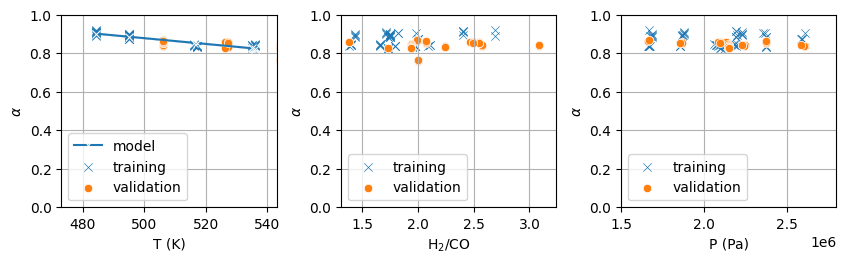

In [26]:
fig, ax = plt.subplots(1,3,figsize=(10,2.5))
plt.subplots_adjust(wspace=0.3)

colors = sns.color_palette()

ax[0].set_xlim(200+273, 270+273)
# sns.regplot(x='T_R_K', y='alpha', data=alphas.loc[data.training], ax = ax[0],
#            line_kws = {'lw': 1.5}, scatter_kws = {'s': 20},
#            label = 'training', marker = 'x', color = colors[0], truncate=False
#            )
sns.lineplot(x='T_R_K', y='alpha_model', data=alphas.loc[data.training],
                ax = ax[0], label = 'model', marker = 'x', color = colors[0])
sns.scatterplot(x='T_R_K', y='alpha', data=alphas.loc[data.training],
                ax = ax[0], label = 'training', marker = 'x', color = colors[0])
sns.scatterplot(x='T_R_K', y='alpha', data=alphas.loc[~data.training],
                ax = ax[0], label = 'validation', marker = 'o', color = colors[1])

ax[0].grid('both')
ax[0].set_ylim(0,1)
ax[0].set_ylabel(r'$\alpha$')
ax[0].set_xlabel('T (K)')

ax[1].set_xlim(0.95 * alphas.H2_CO.min(), 1.05 * alphas.H2_CO.max())
# sns.regplot(x='H2_CO', y='alpha', data=alphas.loc[alphas.training], ax = ax[1],
#            line_kws = {'lw': 1.5}, scatter_kws = {'s': 20},
#            label = 'training', marker = 'x', color = colors[0], truncate=False
#            )
sns.scatterplot(x='H2_CO', y='alpha', data=alphas.loc[alphas.training],
                ax = ax[1], label = 'training', marker = 'x', color = colors[0])
sns.scatterplot(x='H2_CO', y='alpha', data=alphas.loc[~alphas.training],
                ax = ax[1], label = 'validation', marker = 'o', color = colors[1])
ax[1].grid('both')
ax[1].set_ylim(0,1)
ax[1].set_ylabel(r'$\alpha$')
ax[1].set_xlabel(r'$\mathrm{H_2 / CO}$')

ax[1].set_xlim(0.95 * alphas.H2_CO.min(), 1.05 * alphas.H2_CO.max())
# sns.regplot(x='P_abs_Pa', y='alpha', data=alphas.loc[alphas.training], ax = ax[2],
#            line_kws = {'lw': 1.5}, scatter_kws = {'s': 20},
#            label = 'training', marker = 'x', color = colors[0], truncate=False
#            )
sns.scatterplot(x='P_abs_Pa', y='alpha', data=alphas.loc[alphas.training],
                ax = ax[2], label = 'training', marker = 'x', color = colors[0])
sns.scatterplot(x='P_abs_Pa', y='alpha', data=alphas.loc[~alphas.training],
                ax = ax[2], label = 'validation', marker = 'o', color = colors[1])
ax[2].grid('both')
ax[2].set_ylim(0,1)
ax[2].set_xlim(15e5,28e5)
ax[2].set_ylabel(r'$\alpha$')
ax[2].set_xlabel('P (Pa)')

fig_name = 'alpha.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

In [27]:
# visualizing yn
yn_plot = yn_exp.copy()
yn_plot['T_R_K'] = data.T_R_K
yn_plot['T_R_C'] = data.T_R_C
yn_plot['H2_CO'] = data.H2_CO
yn_plot['P_Pa'] = data.P_abs_Pa
yn_plot['index'] = data.index.values
yn_plot = yn_plot.melt(id_vars = ['T_R_K', 'T_R_C', 
                                  'H2_CO', 'P_Pa', 'index'], value_name = 'yn_exp', var_name = 'n')
yn_plot['alpha'] = model_alpha_T.predict(yn_plot.T_R_K.values.reshape(-1, 1))
yn_plot['yn_model'] = ( 1 - yn_plot.alpha.values ) * yn_plot.alpha.values ** ( yn_plot.n.values - 1 )

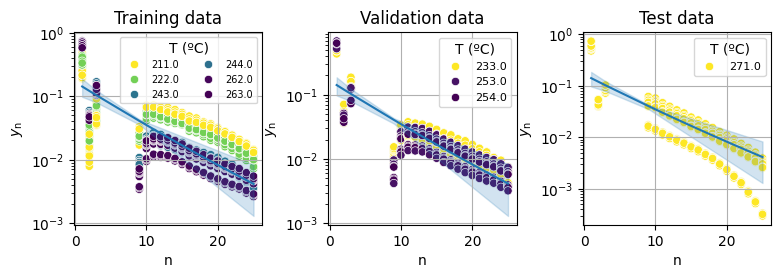

In [28]:
fig, ax = plt.subplots(1,3,figsize=(9, 2.5))
plt.subplots_adjust(wspace=0.35)

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_training)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[0], errorbar = ("pi", 100))

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_\mathrm{n}$')
ax[0].set_yscale('log')
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_validation)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[1], errorbar = ("pi", 100))

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_\mathrm{n}$')
ax[1].set_yscale('log')
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_test)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[2], errorbar = ("pi", 100))

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_\mathrm{n}$')
ax[2].set_yscale('log')
ax[2].set_title('Test data')

# fig_name = 'y_n_distribution.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

plt.show()

In [29]:
alphas.loc[data.training].alpha.mean()

np.float64(0.8687170535603722)

In [30]:
alphas.loc[data.training].alpha.std()

np.float64(0.030434857794553235)

In [31]:
np.save('param_alpha.npy', alpha_params)

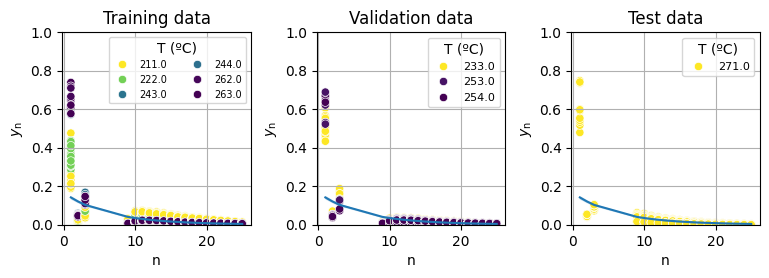

In [32]:
fig, ax = plt.subplots(1,3,figsize=(9, 2.5))
plt.subplots_adjust(wspace=0.35)

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_training)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[0])

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_\mathrm{n}$')
ax[0].set_yscale('linear')
ax[0].set_ylim(0,1)
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_validation)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[1])

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_\mathrm{n}$')
ax[1].set_yscale('linear')
ax[1].set_ylim(0,1)
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot[yn_plot['index'].isin(idx_test)], 
             hue = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_model',
             data=yn_plot, ax = ax[2])

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_\mathrm{n}$')
ax[2].set_yscale('linear')
ax[2].set_ylim(0,1)
ax[2].set_title('Test data')

# fig_name = 'y_n_distribution.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

plt.show()

In [33]:
alpha_params

array([ 1.62628872e+00, -1.49497171e-03])

In [34]:
# now to check the modified activation energies for C1-C2

In [35]:
from models_FTS.Mousavi_C1_C2_Emod import Mousavi 

In [36]:
parafins = [ 'methane', 'ethane', 'propane', 
             # 'butane', 'pentane', 'hexane', 
             #   'heptane', 'octane', 
             'nonane', 'decane', 'undecane', 'dodecane',
               'tridecane', 'tetradecane', 'pentadecane', 'hexadecane', 'heptadecane',
               'octadecane', 'nonadecane', 'eicosane', 'heneicosane', 'docosane',
               'tricosane', 'tetracosane', 'pentacosane',
               'hexacosane', 'heptacosane',
               'octacosane', 'nonacosane', 'triacontane',
             'hentriacontane', 'dotriacontane',
               'tritriacontane', 'tetratriacontane', 'pentatriacontane', 'hexatriacontane'
            ]

olefins = [ 'ethylene',
            # 'propene',
            # '1-butene', '1-pentene', '1-hexene',
            # '1-heptene', '1-octene', 
            '1-nonene', '1-decene',
            '1-undecene', '1-dodecene',
            '1-tridecene', '1-tetradecene', '1-pentadecene',
            '1-hexadecene', '1-heptadecene', '1-octadecene',
          ]

others = ['carbon monoxide', 'hydrogen', 'water', 'carbon dioxide']

In [37]:
def solve_ODEs(index, row):
    results = {}
    F0 = row['F_H2_e_mol_s'] + row['F_CO_e_mol_s']

    H2_CO = row['H2_CO']
    x_CO = 1 / ( 1 + H2_CO )
    x_H2 = 1 - x_CO

    # create reactor object
    T0 = (row['T_R_K'], 'K')
    x0 = {
                      'carbon monoxide': x_CO,
                      'hydrogen' : x_H2,
                  }
    reactor = PBR(T0 = T0, 
                  P0 = (row['P_abs_Pa'], 'Pa'), 
                  x0 = x0, 
                  F0 = (F0, 'mol/s'),
                  isothermal = True, 
                  ergun = False,
                  WT = (row['m_cat_g'], 'g'), 
                  W_steps = 50,
                  U = (300, 'W/m2/K'),
                  D = (7, 'mm'),
                  Dp = (0.1, 'mm'),
                  pellet_density = (2530, 'kg/m3'),
                  Ta = T0,
                  liquid_phase = False,
                  units = 'SI',
                  solver_method = 'BDF',
                  rtol = 1e-5, atol = 1e-7,
                  calculate_equilibrium = False,
                  equilibrium_obj_fun_tolerance = 1e-12,
                  log = True,
                 )

    Mousavi_model = Mousavi()
    reactor.add_model(Mousavi_model)
    reactor.solve()

    sol_df = reactor.sol_dfs['Mousavi']

    for component in parafins + olefins + others:
        results[f'Fout_{component}'] = sol_df.loc[
            (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]

    Q_unit = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')]['value units'].values[-1]
    results[f'Q ({Q_unit})'] = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')].value.values[-1]
    return index, results

In [38]:
data_for_simulation = data[[
    'T_R_K', 'P_abs_Pa', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'm_cat_g', 'H2_CO'
]]

In [39]:
# Determine number of workers (e.g., 4 or use os.cpu_count())
num_workers = 4

print(f"Starting parallel simulation with {num_workers} workers...")

# Prepare the list of tasks
tasks = [(idx, row) for idx, row in data_for_simulation.iterrows()]

# Execute in parallel
results_list = []
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # We use a wrapper or starmap-like approach
    futures = [executor.submit(solve_ODEs, *task) for task in tasks]
    
    for future in tqdm(futures, total=len(futures)):
        idx, res = future.result()
        # Update the dataframe with results
        for col, val in res.items():
            data_for_simulation.loc[idx, col] = val

# Save final results
data_for_simulation.to_pickle('simulations_Mousavi_C1_C2mod.pkl')
data_for_simulation.to_excel('simulations_Mousavi_C1_C2mod.ods')
print("Simulations complete.")

Starting parallel simulation with 4 workers...


  0%|          | 0/96 [00:00<?, ?it/s]

Simulations complete.


In [40]:
data_for_simulation = pd.read_pickle('simulations_Mousavi_C1_C2mod.pkl')

In [41]:
cols_Fout = [f'Fout_{comp}' for comp in parafins + olefins + others] 

In [42]:
from models_FTS.chain_length import n_parafins, n_olefins 

In [43]:
N = {}
for comp in parafins:
    N[f'Fout_{comp}'] = n_parafins[comp]
for comp in olefins:
    N[f'Fout_{comp}'] = n_olefins[comp]

In [44]:
cols_Fout_C1_C8 = ['Fout_methane',
 'Fout_ethane',
 'Fout_propane',
 # 'Fout_butane',
 # 'Fout_pentane',
 # 'Fout_hexane',
 # 'Fout_heptane',
 # 'Fout_octane',
 'Fout_ethylene',
 # 'Fout_propene',
 # 'Fout_1-butene',
 # 'Fout_1-pentene',
 # 'Fout_1-hexene',
 # 'Fout_1-heptene',
 # 'Fout_1-octene'
                  ]

In [45]:
cols_Fout_C9_C15 = [
 'Fout_nonane',
 'Fout_decane',
 'Fout_undecane',
 'Fout_dodecane',
 'Fout_tridecane',
 'Fout_tetradecane',
 'Fout_pentadecane',
 'Fout_1-nonene',
 'Fout_1-decene',
 'Fout_1-undecene',
 'Fout_1-dodecene',
 'Fout_1-tridecene',
 'Fout_1-tetradecene',
 'Fout_1-pentadecene',
]

In [51]:
cols_Fout_C16p = [
 'Fout_hexadecane',
 'Fout_heptadecane',
 'Fout_octadecane',
 'Fout_nonadecane',
 'Fout_eicosane',
 'Fout_heneicosane',
 'Fout_docosane',
 'Fout_tricosane',
 'Fout_tetracosane',
 'Fout_pentacosane',
 # 'Fout_hexacosane',
 # 'Fout_heptacosane',
 # 'Fout_octacosane',
 # 'Fout_nonacosane',
 # 'Fout_triacontane',
 # 'Fout_hentriacontane',
 # 'Fout_dotriacontane',
 # 'Fout_tritriacontane',
 # 'Fout_tetratriacontane',
 # 'Fout_pentatriacontane',
 # 'Fout_hexatriacontane',
 # 'Fout_1-hexadecene',
 # 'Fout_1-heptadecene',
 # 'Fout_1-octadecene',
]

In [52]:
Fn_model = data_for_simulation[N.keys()].T.groupby(N).sum().T

In [53]:
yn_C1_C1_model = Fn_model.div(Fn_model.sum(axis = 'columns'), axis = 'rows')

In [54]:
yn_plot['yn_C1_C1_mod_model'] = yn_C1_C1_model.melt().value

In [55]:
yn_plot['data_set'] = 'training'
yn_plot.loc[yn_plot['index'].isin(idx_test) ,'data_set'] = 'test'
yn_plot.loc[yn_plot['index'].isin(idx_validation) ,'data_set'] = 'validation'

In [56]:
X = yn_plot[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

yn_plot['cluster_T'] = clustering.labels_

In [57]:
yn_plot_mean = yn_plot.groupby(['cluster_T', 'n', 'data_set']).mean()

In [58]:
yn_plot_mean['T_R_C'] = yn_plot_mean['T_R_C'].round(0)

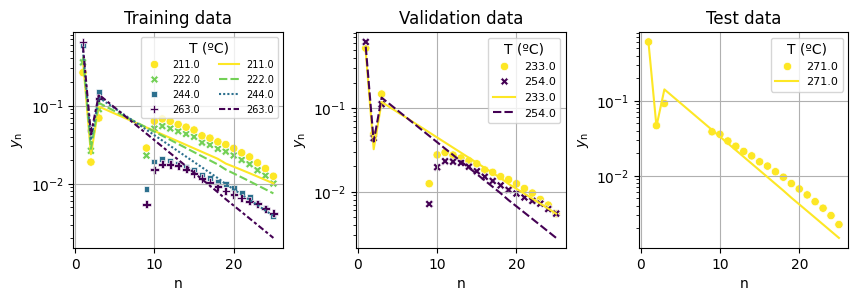

In [59]:
fig, ax = plt.subplots(1,3,figsize=(10, 2.8))
plt.subplots_adjust(wspace=0.35)

scale = 'log'

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], ax = ax[0],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_\mathrm{n}$')
ax[0].set_yscale(scale)
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], ax = ax[1],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_\mathrm{n}$')
ax[1].set_yscale(scale)
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], ax = ax[2],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_\mathrm{n}$')
ax[2].set_yscale(scale)
ax[2].set_title('Test data')

fig_name = 'y_n_distribution.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

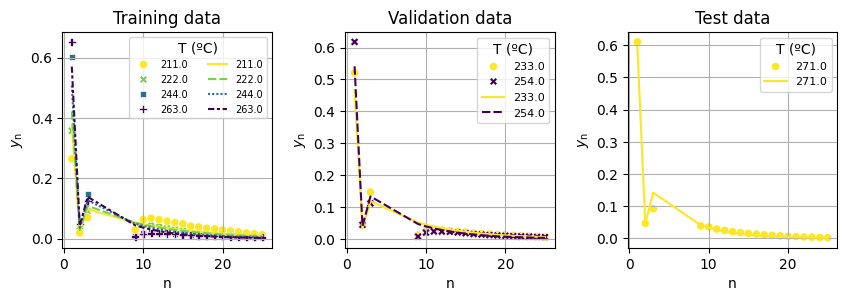

In [60]:
fig, ax = plt.subplots(1,3,figsize=(10, 2.8))
plt.subplots_adjust(wspace=0.35)

scale = 'linear'

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], ax = ax[0],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_\mathrm{n}$')
ax[0].set_yscale(scale)
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], ax = ax[1],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_\mathrm{n}$')
ax[1].set_yscale(scale)
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], ax = ax[2],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_\mathrm{n}$')
ax[2].set_yscale(scale)
ax[2].set_title('Test data')

# fig_name = 'y_n_distribution.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

plt.show()